In [73]:
from pathlib import Path
from tqdm import tqdm

import os, re, math
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
import os
import matplotlib.image as mpimg

In [78]:
model_name = 'CVPR2024-FAS'  # MVP-FAS | DMFC-FAS | CVPR2024-FAS

path_model = Path(model_name)
path_res = path_model / 'combined_scores_plot.png'

path_model

WindowsPath('CVPR2024-FAS')

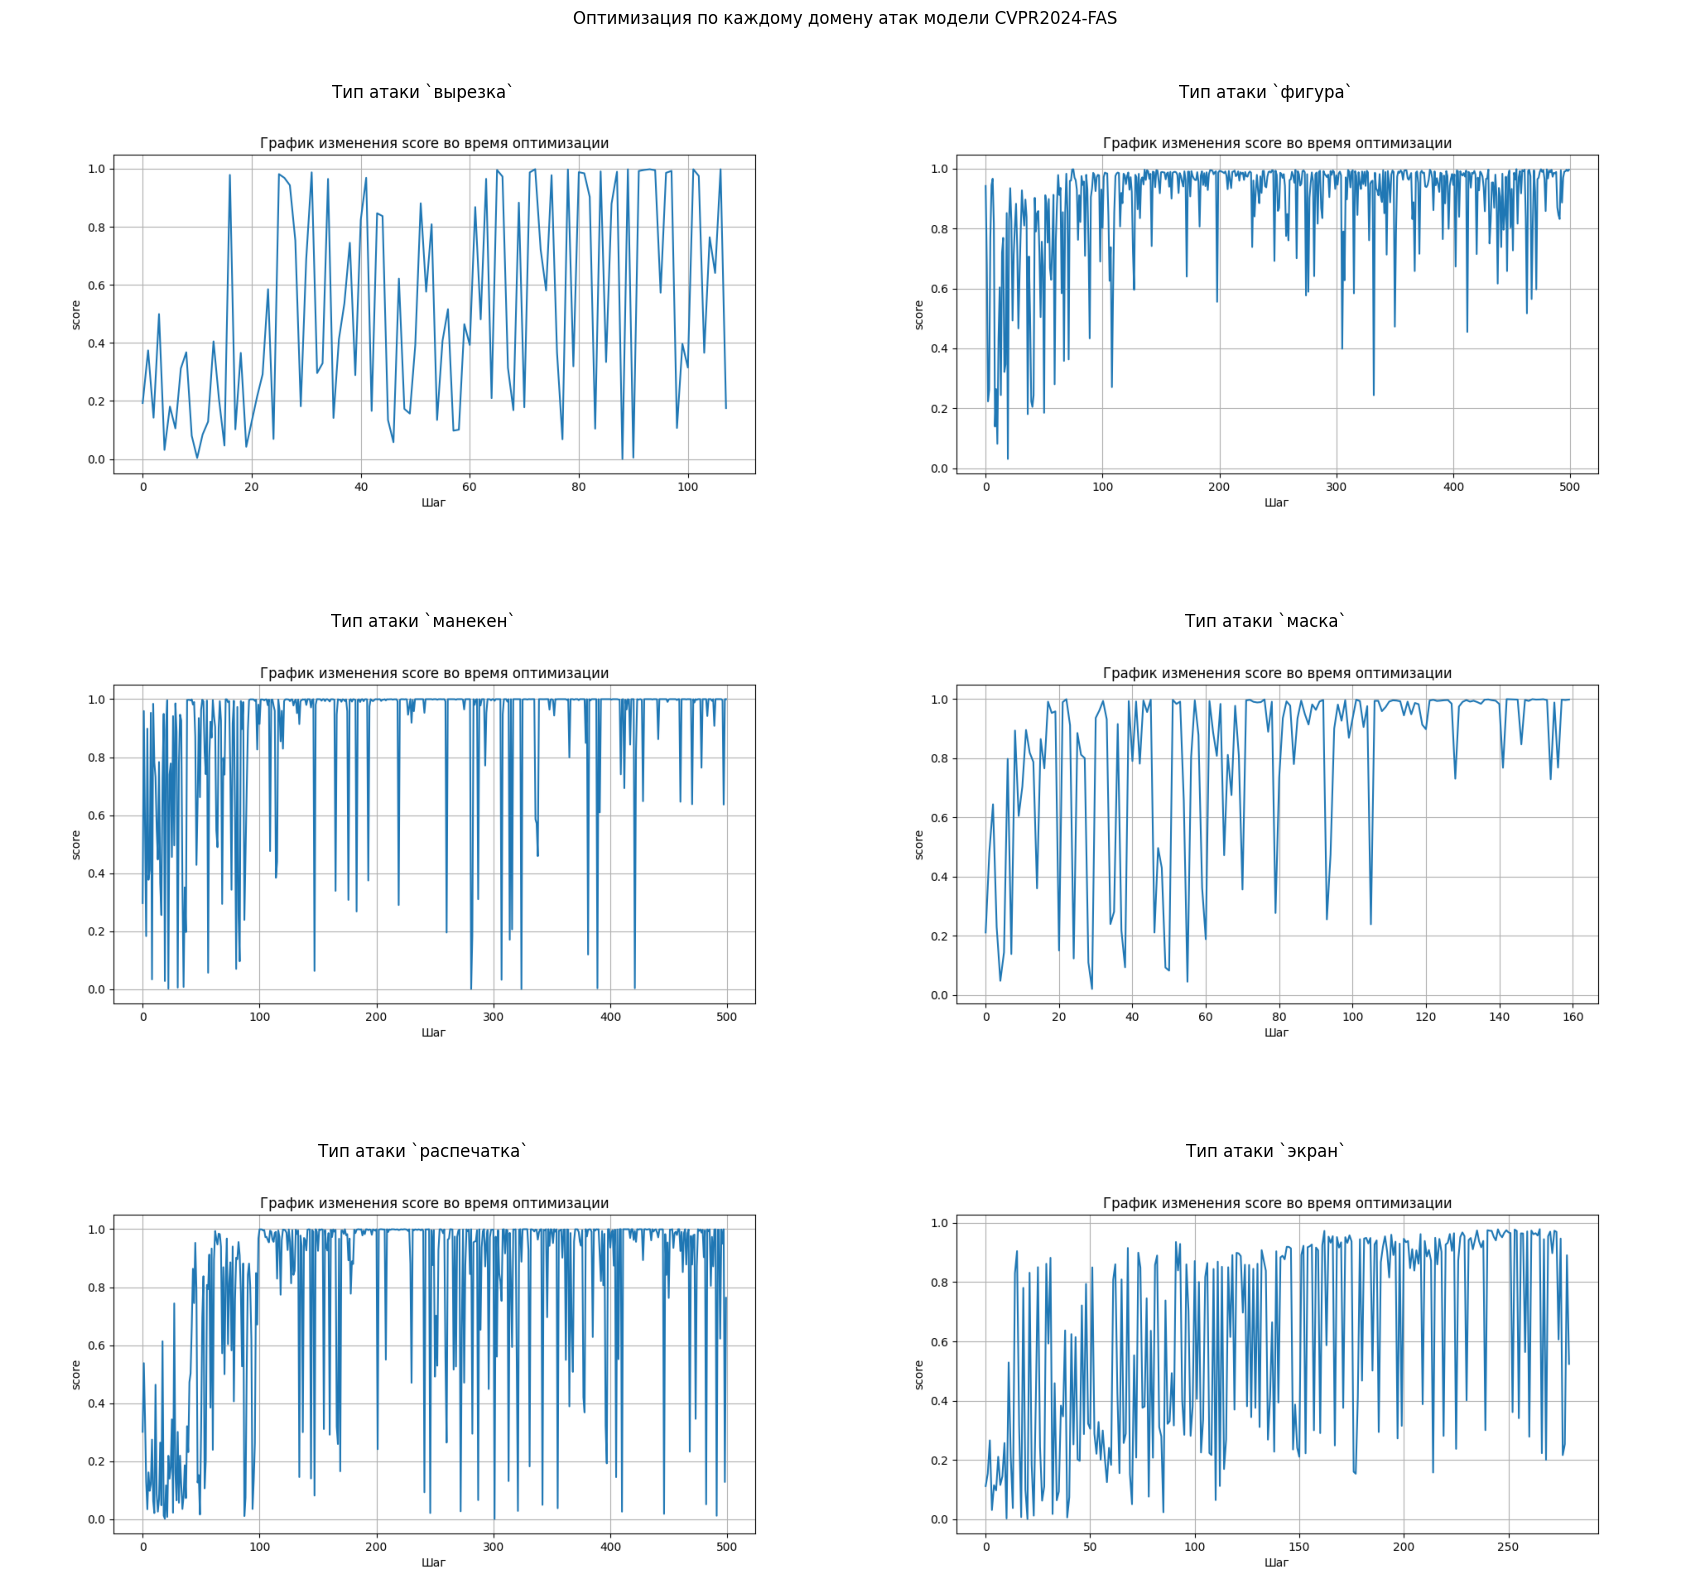

In [79]:
list_domain = ['cutout', 'figure', 'mannequin', 'mask', 'print', 'screen']
list_domain_rus = ['вырезка', 'фигура', 'манекен', 'маска', 'распечатка', 'экран']

fig, axes = plt.subplots(3, 2, figsize=(17, 17))
fig.suptitle(f"Оптимизация по каждому домену атак модели {model_name}")

i = 0
for ax, domain_name in zip(axes.flat, list_domain):
    path = path_model / domain_name / 'scores_plot.png'
    img = mpimg.imread(path)
    
    ax.imshow(img)
    ax.set_title(f'Тип атаки `{list_domain_rus[i]}`')
    ax.axis('off')
    i += 1

plt.tight_layout()
plt.savefig(path_model / 'combined_scores_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [96]:
from PIL import Image
import os

# Настройки
# path_model = Path('CVPR2024-FAS')
# list_domain = ['cutout', 'figure', 'mannequin', 'mask', 'print', 'screen']
# list_domain_rus = ['вырезка', 'фигура', 'манекен', 'маска', 'распечатка', 'экран']

path_model = Path('MVP-FAS similarity')
list_domain = ['figure similarity w=0,5', 'figure similarity w=0,3', 'figure similarity w=0,1']
list_domain_rus = ['фигура w=0,5', 'фигура w=0,3', 'фигура w=0,1']

rows, cols = 2, 2
gap = 5  # Расстояние между графиками (px)
margin = 5  # Поля вокруг всего изображения (px)
title_height = 20  # Высота места под заголовок

# 1. Загружаем все изображения и находим максимальный размер
images = []
i = 0
for domain in list_domain:
    path = path_model / domain / 'scores_plot.png'
    img = Image.open(path)
    images.append((f'Тип атаки `{list_domain_rus[i]}`', img))
    i += 1

# Берем размер первого изображения как эталон (или можно найти max)
base_w, base_h = images[0][1].size
# Если картинки разного размера, раскомментируйте строки ниже, чтобы подогнать все под максимум:
# base_w = max(img.size[0] for _, img in images)
# base_h = max(img.size[1] for _, img in images)

# 2. Вычисляем размеры итогового холста
total_w = cols * base_w + (cols - 1) * gap + 2 * margin
total_h = rows * (base_h + title_height) + (rows - 1) * gap + 2 * margin

# Создаем белый фон
result = Image.new('RGB', (total_w, total_h), 'white')

# 3. Вставляем изображения и подписи
for i, (fname, img) in enumerate(images):
    row = i // cols
    col = i % cols
    
    # Координаты верхнего левого угла картинки
    x = margin + col * (base_w + gap)
    y = margin + row * (base_h + title_height + gap) + title_height
    
    # Если картинка меньше эталона, центрируем её (опционально)
    if img.size != (base_w, base_h):
        img = img.resize((base_w, base_h), Image.Resampling.LANCZOS)
    
    result.paste(img, (x, y))
    
    # Добавляем текст заголовка (требуется шрифт, используем стандартный если нет ttf)
    from PIL import ImageDraw, ImageFont
    draw = ImageDraw.Draw(result)
    try:
        # Попытка загрузить красивый шрифт (размер 20)
        font = ImageFont.truetype("arial.ttf", 25)
    except IOError:
        font = ImageFont.load_default()
    
    text_x = x + (base_w - draw.textlength(fname, font=font)) / 2
    text_y = margin + row * (base_h + title_height + gap)
    
    draw.text((text_x, text_y), fname, fill='black', font=font)

# Сохраняем
result.save(path_model / 'combined_scores_plot.png')
print("Готово")

Готово
